<a href="https://colab.research.google.com/github/Kaveh-Ramezani/202610ELC536501/blob/main/3/FuncAppr_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Train a two-layer neural network to approximate a 2D function

### 1.  The first imports

In [58]:
# %tensorflow_version 1.x
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt

### 2. Sigmoid Function

In [59]:
def Sigmoid(x):
    return 1/(1 + np.exp(-x))
# Sigmoid function suffers from the problem of "vanishing gradients" as it flattens out at both ends, resulting in very small changes in the weights during backpropagation. This can make the neural network refuse to learn and get stuck.
# Due to this reason, usage of the sigmoid function is being replaced by other non-linear functions such as Rectified Linear Unit (ReLU).

# Visualization of the target function, functions



In [60]:
def visualize_original(Width,Height,U,V):
    H2 = np.empty((Height,Width))
    for i in range(Width):
        u = U * ((i - Width/2.0) / (Width/2.0))
        for j in range(Height):
            v = V *((j - Height/2.0) / (Height/2.0))
            H2[j,i] = np.sin(3.14*u/2.0)*np.cos(3.14*v/4.0)  #The 2D func

    return H2


# Visualize combined functions

In [61]:
def visualize_2layer(Width,Height,U,V,W1,b1,W2,b2):
    H2 = np.empty((Height,Width))
    for i in range(Width):
        u = U * ((i - Width/2.0) / (Width/2.0))
        for j in range(Height):
            v = V *((j - Height/2.0) / (Height/2.0))
            x = [u,v]
            h1 = np.vectorize(Sigmoid)(x*W1+b1)
            h2 = h1 * W2 + b2
            H2[j,i] = h2[0,0]

    return H2

# The 2D function to be modeled

In [62]:
#The 2D function that is to be modeled
def F_mv(x1,x2):
    return np.sin(3.14*x1/2.0)*np.cos(3.14*x2/4.0)

# Generating Training Data

In [63]:
#Generate training data
A = 2
nb_samples = 1000
F = F_mv
X_train = np.random.uniform(-A,A,(nb_samples,2))

Y_train = np.zeros(shape=(nb_samples,1))

for i in range(nb_samples):
    Y_train[i] = [F(X_train[i][0],X_train[i][1])]


# Making the nural network

In [64]:
#Two-Layer Neural Network Structure
N1 = 20  #Number of neurons in the hidden layer

tf.reset_default_graph()
session = tf.InteractiveSession()
# The input layer
with tf.variable_scope("Input"):
    # The input layer with two inputs
    x = tf.placeholder(tf.float32,shape=[None,2])
# The Hidden Layer
with tf.variable_scope("HiddenLayer"):
    # The weight.
    # For each neuron we have:
    #   1. Two inputs (From input layer), and
    #   2. N1 outputs (to hidden layer)
    # Each weight
    W1 = tf.Variable(tf.truncated_normal([2,N1],stddev=np.sqrt(6/(2+N1))))
    b1 = tf.Variable(tf.zeros([N1]))
    h1 = tf.nn.sigmoid(tf.add(tf.matmul(x,W1),b1))

with tf.variable_scope("OutputLayer"):
    W2 = tf.Variable(tf.truncated_normal([N1,1],stddev=np.sqrt(6/(2+N1))))
    b2 = tf.Variable(tf.zeros([1]))
    h2 = tf.add(tf.matmul(h1,W2),b2)

with tf.variable_scope("Output"):
    y = tf.placeholder(tf.float32,[None,1])

with tf.variable_scope("Loss"):
    Loss = tf.reduce_sum(tf.square(h2 - y))

ERROR:tensorflow:An interactive session is already active. This can cause out-of-memory errors or some other unexpected errors (due to the unpredictable timing of garbage collection) in some cases. You must explicitly call `InteractiveSession.close()` to release resources held by the other session(s). Please use `tf.Session()` if you intend to productionize.


# Optimization

In [65]:
#Optimization
eta = 1e-3
optimizer = tf.train.GradientDescentOptimizer(eta)
optimizer_one_step = optimizer.minimize(Loss)
session.run(tf.global_variables_initializer())

# File_Writer = tf.summary.FileWriter('.\\TwoLayergraph',session.graph)

epochs = int(1e4)
batch_size = 100
epochs_between_two_evaluations = 1e3

for i in range(epochs):
    idx = np.random.permutation(X_train.shape[0])[:batch_size]
    feed_dict = {x:X_train[idx],y:Y_train[idx]}
    optimizer_one_step.run(feed_dict=feed_dict)
    if i % epochs_between_two_evaluations == 0:
        [curr_loss] = session.run([Loss],{x:X_train,y:Y_train})
        print(curr_loss)

412.5798
64.37732
13.198022
7.2550917
4.2971635
3.0340075
2.684167
2.0886474
1.9673738
1.7114215


# Visualization

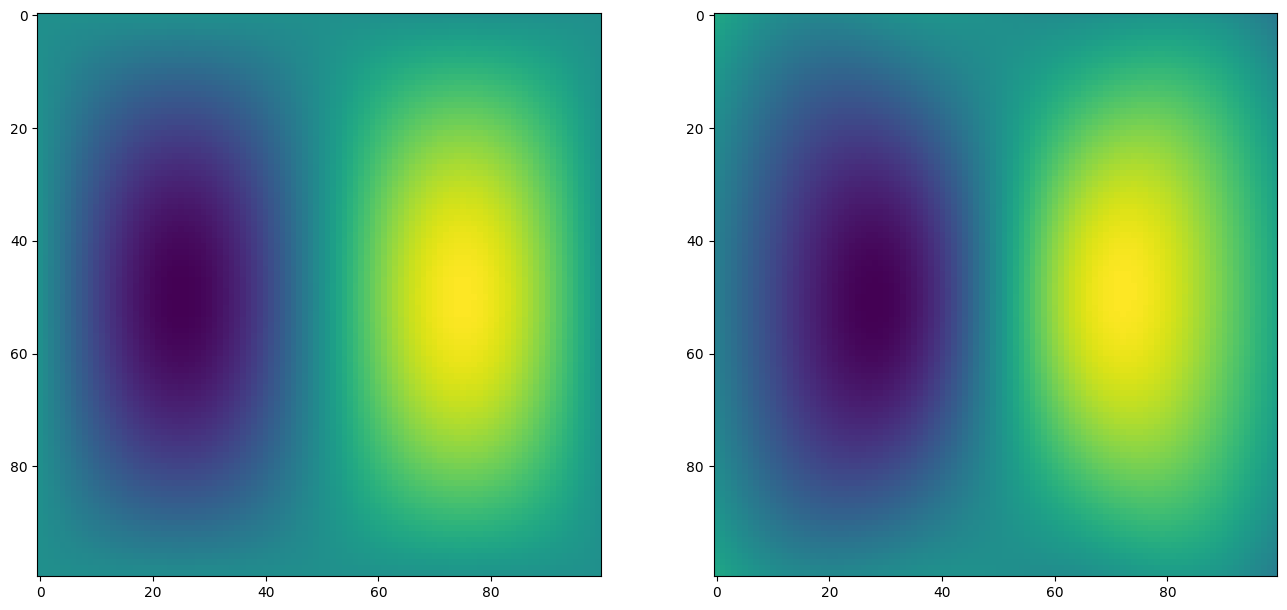

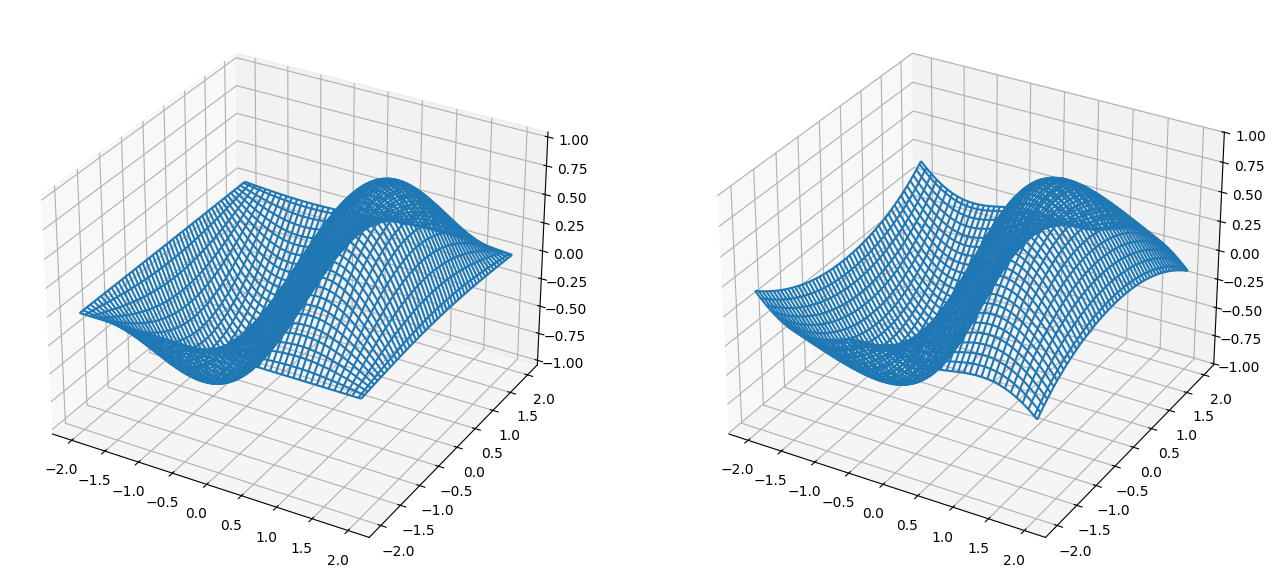

In [66]:
#Visualize the predicted function
[curr_W1,curr_b1,curr_W2,curr_b2,curr_loss] = session.run([W1,b1,W2,b2,Loss],{x:X_train,y:Y_train})

curr_W1 = np.asmatrix(curr_W1)
curr_W2 = np.asmatrix(curr_W2)

I_original = visualize_original(100,100,A,A)

I = visualize_2layer(100,100,A,A,curr_W1,curr_b1,curr_W2,curr_b2)

f = plt.figure(figsize=(16, 8))

f.add_subplot(1,2, 1)
plt.imshow(I_original)
f.add_subplot(1,2, 2)
plt.imshow(I)
#plt.show(block=True)

x = np.linspace(-A, A, 100)
y = np.linspace(-A, A, 100)
X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(121,projection='3d')
ax1.plot_wireframe(X, Y, I_original)
ax2 = fig.add_subplot(122,projection='3d')
ax2.plot_wireframe(X, Y, I)

session.close()